# 6단계 · 시장 국면 판별 전략

## 개요
**MA 정렬 + ADX 조합** — 기관·퀀트에서 가장 널리 쓰이는 시장 국면 판별 방법입니다.

| 국면 | 판별 조건 | 적용 전략 | 매수 방식 | 매수 대상 | 매도 방식 | 매도 대상 |
|------|----------|----------|----------|----------|----------|----------|
| **상승 추세장 (UPTREND)** | MA20 > MA60 > MA120 AND ADX > 25 | 추세 추종 (골든크로스) | 신규 매수 | 골든크로스 발생 종목 | 손절 | 손실 발생 개별 종목 |
| **하락 추세장 (DOWNTREND)** | MA20 < MA60 < MA120 AND ADX > 25 | 전량 청산 → 현금 보유 | 매수 없음 | — | 전량 청산 | 보유 종목 전체 |
| **횡보장 (SIDEWAYS)** | ADX < 20 | 볼린저 밴드 (평균 회귀) | 하단 터치 시 매수 | 볼린저 밴드 하단 접촉 종목 | 손절 | 손실 발생 개별 종목 |
| **전환 구간 (TRANSITION)** | 위 3가지 조건 미해당 | 신규 진입 차단, 기존 포지션 유지 | 매수 없음 | — | 손절만 유지 | 손실 발생 개별 종목 |

### 매수/매도 방식 상세

| 구분 | 방식 | 대상 | 발동 조건 | 목적 |
|------|------|------|----------|------|
| **매수** | 신규 매수 | 개별 종목 | 골든크로스 or 볼린저 밴드 하단 접촉 | 수익 기회 포착 |
| **매도** | 손절 (Stop Loss) | 개별 종목 | 해당 종목 -N% 손실 도달 시 | 개별 종목 손실 제한 |
| **매도** | 전량 청산 (Sell All) | 보유 종목 전체 | 국면이 DOWNTREND 전환 시 | 시장 전체 리스크 회피 |

### 판별 우선순위
1. ADX < 20 → SIDEWAYS
2. MA20 > MA60 > MA120 AND ADX > 25 → UPTREND
3. MA20 < MA60 < MA120 AND ADX > 25 → DOWNTREND
4. 그 외 → TRANSITION (신규 진입만 차단, 기존 포지션 유지)

### 파라미터 기본값
- MA: 20일 / 60일 / 120일
- ADX 추세 임계값: 25
- ADX 횡보 임계값: 20
- ADX 기간: 14일
- 손절 기준: -5% (개별 종목)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import vectorbt as vbt
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 (삼성전자 2019~2024) ── 07번과 동일 조건
TICKER = '005930.KS'
START  = '2019-01-01'
END    = '2024-12-31'

df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

close  = df['Close'].squeeze()
high   = df['High'].squeeze()
low    = df['Low'].squeeze()
volume = df['Volume'].squeeze()

print(f'종목  : 삼성전자 ({TICKER})')
print(f'기간  : {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'거래일: {len(close)}일')
print(f'시작가: {close.iloc[0]:,.0f}원  /  종가: {close.iloc[-1]:,.0f}원')

종목  : 삼성전자 (005930.KS)
기간  : 2019-01-02 ~ 2024-12-30
거래일: 1475일
시작가: 32,297원  /  종가: 51,969원


---
## 1단계 · MA 3중 구조 (20 / 60 / 120)

### 정렬 패턴 해석

```
MA20 > MA60 > MA120  → 단기·중기·장기 모두 상승 정렬 = 강한 상승 추세
MA20 < MA60 < MA120  → 단기·중기·장기 모두 하락 정렬 = 강한 하락 추세
MA20 ≈ MA60 교차 반복 → 방향성 없음 = 횡보장
MA20 < MA60 > MA120  → 중기 꺾임, 장기 유효 = 조정 구간
```

### MA 기간이 20/60/120인 이유
| MA | 거래일 기준 | 의미 |
|----|------------|------|
| MA20 | 약 1개월 | 단기 시장 심리 |
| MA60 | 약 3개월(분기) | 중기 추세, 실적 사이클과 정합 |
| MA120 | 약 6개월(반기) | 장기 추세, 섹터 순환과 정합 |

In [2]:
# ─── MA 3중 구조 계산 ──────────────────────────────────────────────
ma20  = close.rolling(20).mean()
ma60  = close.rolling(60).mean()
ma120 = close.rolling(120).mean()

# ─── 정렬 상태 판별 ────────────────────────────────────────────────
bull_align = (ma20 > ma60) & (ma60 > ma120)   # 상승 정렬
bear_align = (ma20 < ma60) & (ma60 < ma120)   # 하락 정렬
mixed      = ~bull_align & ~bear_align         # 혼재 (횡보/조정)

print('=== MA 정렬 상태 분포 ===')
print(f'상승 정렬 (Bull): {bull_align.sum()}일 ({bull_align.mean():.1%})')
print(f'하락 정렬 (Bear): {bear_align.sum()}일 ({bear_align.mean():.1%})')
print(f'혼재 (횡보/조정): {mixed.sum()}일 ({mixed.mean():.1%})')

=== MA 정렬 상태 분포 ===
상승 정렬 (Bull): 578일 (39.2%)
하락 정렬 (Bear): 360일 (24.4%)
혼재 (횡보/조정): 537일 (36.4%)


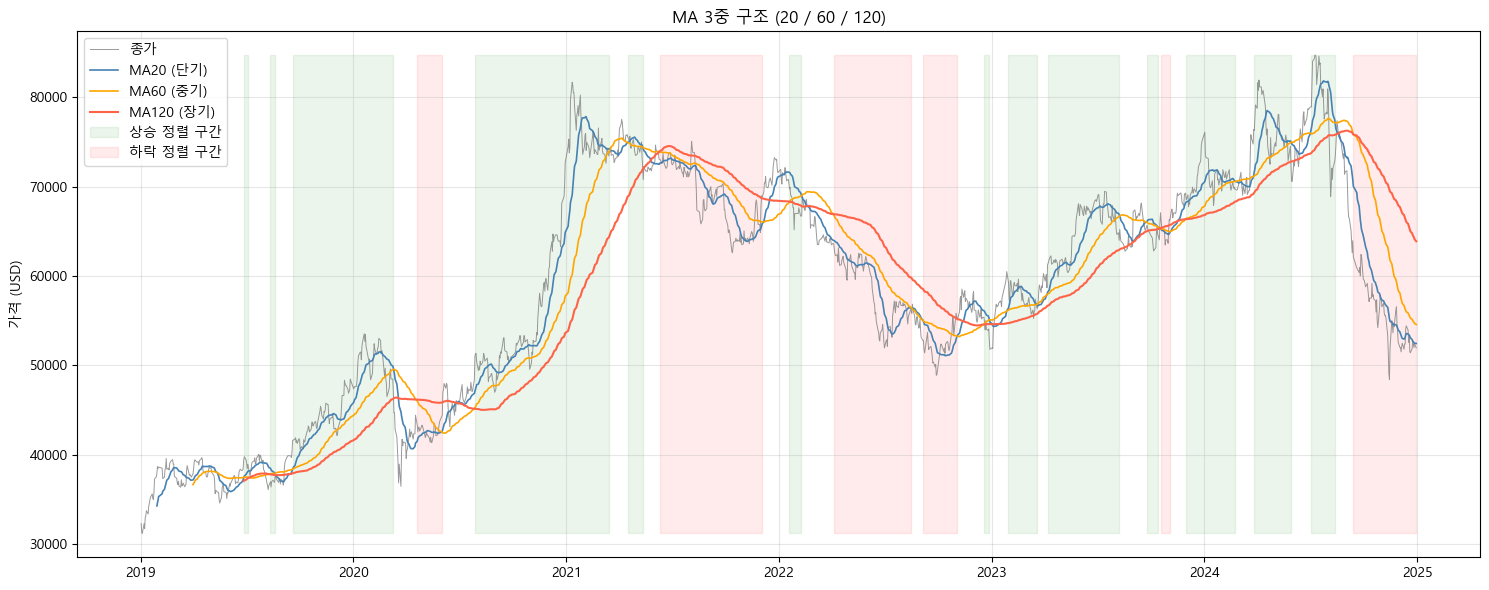

In [3]:
# ─── MA 3중 구조 시각화 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(close,  color='gray',      linewidth=0.7, alpha=0.8, label='종가')
ax.plot(ma20,   color='steelblue', linewidth=1.2, label='MA20 (단기)')
ax.plot(ma60,   color='orange',    linewidth=1.2, label='MA60 (중기)')
ax.plot(ma120,  color='tomato',    linewidth=1.5, label='MA120 (장기)')

# 상승 정렬 구간 배경 표시
ax.fill_between(close.index, close.min(), close.max(),
                where=bull_align, alpha=0.08, color='green', label='상승 정렬 구간')
ax.fill_between(close.index, close.min(), close.max(),
                where=bear_align, alpha=0.08, color='red', label='하락 정렬 구간')

ax.set_title('MA 3중 구조 (20 / 60 / 120)')
ax.set_ylabel('가격 (USD)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2단계 · ADX 추세 강도 확인

MA 정렬만으로는 추세가 실제로 힘이 있는지 알 수 없습니다.  
ADX를 추가해 **정렬 + 강도** 두 조건을 모두 충족할 때만 추세장으로 확정합니다.

```
ADX < 20   → 추세 약함 (횡보 가능성)
ADX 20~25  → 과도기 (관망)
ADX 25~40  → 중간 추세 (진입 적기)
ADX > 40   → 강한 추세 (추격 매수 주의)
```

In [4]:
# ─── ADX 계산 (vbt_backtest 모듈 활용) ────────────────────────────
from vbt_backtest.strategies.indicators.adx_strategy import calc_adx

adx_df   = calc_adx(high, low, close, window=14)
adx      = adx_df['ADX']
plus_di  = adx_df['plus_di']
minus_di = adx_df['minus_di']

print('=== ADX 통계 ===')
print(f'평균 ADX: {adx.mean():.1f}')
print(f'ADX < 20 (횡보):    {(adx < 20).sum()}일 ({(adx < 20).mean():.1%})')
print(f'ADX 20~25 (과도기): {((adx >= 20) & (adx < 25)).sum()}일')
print(f'ADX > 25 (추세장):  {(adx > 25).sum()}일 ({(adx > 25).mean():.1%})')
print(f'ADX > 40 (강추세):  {(adx > 40).sum()}일 ({(adx > 40).mean():.1%})')

=== ADX 통계 ===
평균 ADX: 22.9
ADX < 20 (횡보):    689일 (46.7%)
ADX 20~25 (과도기): 273일
ADX > 25 (추세장):  500일 (33.9%)
ADX > 40 (강추세):  97일 (6.6%)


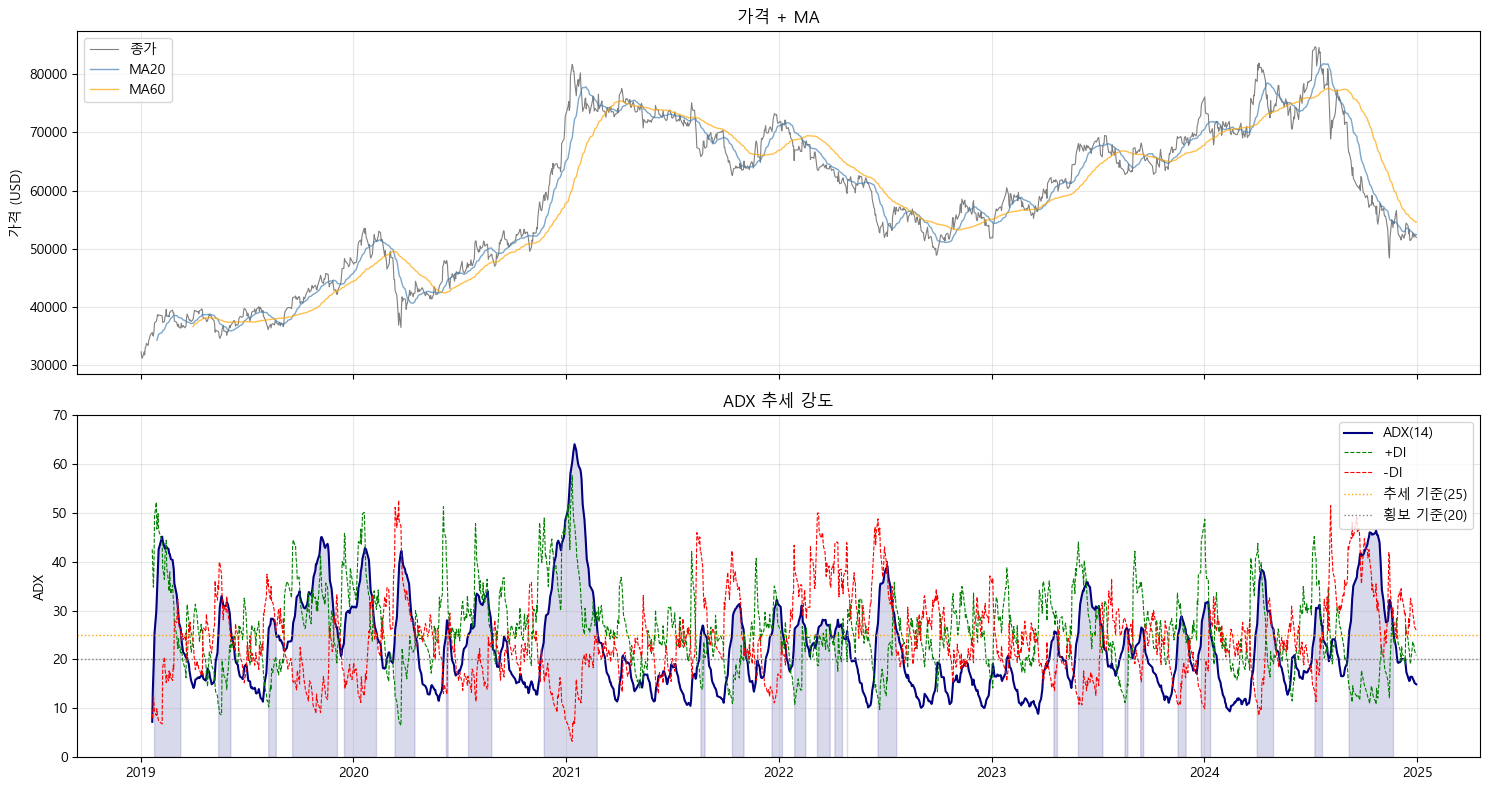

In [5]:
# ─── ADX 시각화 ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(close, color='gray', linewidth=0.8, label='종가')
ax1.plot(ma20,  color='steelblue', linewidth=1.0, alpha=0.7, label='MA20')
ax1.plot(ma60,  color='orange',    linewidth=1.0, alpha=0.7, label='MA60')
ax1.set_title('가격 + MA')
ax1.set_ylabel('가격 (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(adx,      color='navy',   linewidth=1.5, label='ADX(14)')
ax2.plot(plus_di,  color='green',  linewidth=0.8, linestyle='--', label='+DI')
ax2.plot(minus_di, color='red',    linewidth=0.8, linestyle='--', label='-DI')
ax2.axhline(25, color='orange', linewidth=1.0, linestyle=':', label='추세 기준(25)')
ax2.axhline(20, color='gray',   linewidth=1.0, linestyle=':', label='횡보 기준(20)')
ax2.fill_between(adx.index, 0, adx, where=(adx > 25), alpha=0.15, color='navy')
ax2.set_title('ADX 추세 강도')
ax2.set_ylabel('ADX')
ax2.set_ylim(0, 70)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3단계 · 시장 국면 자동 판별

MA 정렬 + ADX를 결합해 **4가지 국면**으로 분류합니다.

| 국면 | 판별 조건 | 색상 |
|------|---------|------|
| 상승 추세 (UPTREND) | MA20 > MA60 > MA120 AND ADX > 25 | 초록 |
| 하락 추세 (DOWNTREND) | MA20 < MA60 < MA120 AND ADX > 25 | 빨강 |
| 횡보장 (SIDEWAYS) | ADX < 20 | 회색 |
| 전환 구간 (TRANSITION) | 위 3가지 조건 미해당 | 노랑 |

### 판별 우선순위
1. ADX < 20 → **SIDEWAYS** (먼저 확인)
2. MA20 > MA60 > MA120 AND ADX > 25 → **UPTREND**
3. MA20 < MA60 < MA120 AND ADX > 25 → **DOWNTREND**
4. 그 외 → **TRANSITION**

In [6]:
# ─── 시장 국면 분류 (4국면, 우선순위 적용) ─────────────────────────
# 우선순위: SIDEWAYS → UPTREND → DOWNTREND → TRANSITION
SIDEWAYS   = adx < 20
UPTREND    = (ma20 > ma60) & (ma60 > ma120) & (adx > 25) & ~SIDEWAYS
DOWNTREND  = (ma20 < ma60) & (ma60 < ma120) & (adx > 25) & ~SIDEWAYS
TRANSITION = ~SIDEWAYS & ~UPTREND & ~DOWNTREND

# 국면 라벨 Series
regime = pd.Series('TRANSITION', index=close.index)
regime[SIDEWAYS]  = 'SIDEWAYS'
regime[UPTREND]   = 'UPTREND'
regime[DOWNTREND] = 'DOWNTREND'

print('=== 시장 국면 분포 ===')
counts = regime.value_counts()
for name, cnt in counts.items():
    print(f'  {name:12s}: {cnt}일 ({cnt/len(regime):.1%})')

=== 시장 국면 분포 ===
  SIDEWAYS    : 689일 (46.7%)
  TRANSITION  : 427일 (28.9%)
  UPTREND     : 258일 (17.5%)
  DOWNTREND   : 101일 (6.8%)


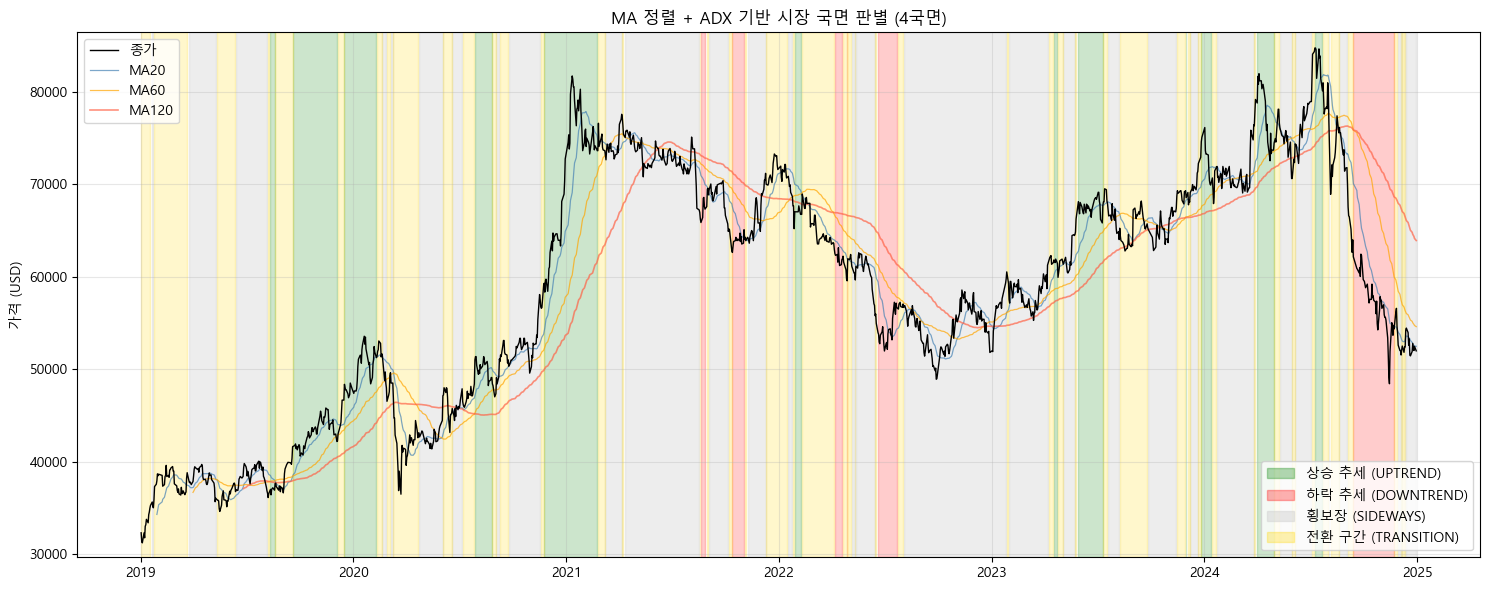

In [7]:
# ─── 국면별 가격 차트 시각화 ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

regime_styles = {
    'UPTREND':    (UPTREND,    'green',      '상승 추세 (UPTREND)',    0.20),
    'DOWNTREND':  (DOWNTREND,  'red',        '하락 추세 (DOWNTREND)',  0.20),
    'SIDEWAYS':   (SIDEWAYS,   'lightgray',  '횡보장 (SIDEWAYS)',      0.40),
    'TRANSITION': (TRANSITION, 'gold',       '전환 구간 (TRANSITION)', 0.20),
}

ymin, ymax = close.min() * 0.95, close.max() * 1.02
patches = []
for key, (mask, color, label, alpha) in regime_styles.items():
    ax.fill_between(close.index, ymin, ymax, where=mask,
                    color=color, alpha=alpha)
    patches.append(mpatches.Patch(color=color, alpha=alpha + 0.1, label=label))

ax.plot(close, color='black', linewidth=1.0, label='종가', zorder=5)
ax.plot(ma20,  color='steelblue', linewidth=0.9, alpha=0.7, label='MA20')
ax.plot(ma60,  color='orange',    linewidth=0.9, alpha=0.7, label='MA60')
ax.plot(ma120, color='tomato',    linewidth=1.2, alpha=0.7, label='MA120')

ax.set_title('MA 정렬 + ADX 기반 시장 국면 판별 (4국면)')
ax.set_ylabel('가격 (USD)')
ax.set_ylim(ymin, ymax)
line_legend = ax.legend(loc='upper left')
ax.add_artist(line_legend)
ax.legend(handles=patches, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4단계 · 국면별 전략 적용

### 4국면 매수/매도 전략 매핑

| 국면 | 적용 전략 | 매수 방식 | 매수 대상 | 매도 방식 | 매도 대상 |
|------|----------|----------|----------|----------|----------|
| **UPTREND** | 추세 추종 (골든크로스) | 신규 매수 | 골든크로스 발생 종목 | 손절 | 손실 발생 개별 종목 |
| **DOWNTREND** | 전량 청산 → 현금 보유 | 매수 없음 | — | 전량 청산 | 보유 종목 전체 |
| **SIDEWAYS** | 볼린저 밴드 (평균 회귀) | 하단 터치 시 매수 | 볼린저 밴드 하단 접촉 종목 | 손절 | 손실 발생 개별 종목 |
| **TRANSITION** | 신규 진입 차단, 기존 포지션 유지 | 매수 없음 | — | 손절만 유지 | 손실 발생 개별 종목 |

### TRANSITION 처리 방식 변경 이유
- 기존: 전량 청산 → MA120 후행성으로 인해 너무 이른 청산, 수익 기회 손실
- 변경: **신규 진입만 차단** → 기존 포지션은 전략 청산 신호(손절·골든크로스 데드크로스)까지 유지

### 매도 방식 상세

| 매도 방식 | 대상 | 발동 조건 | 목적 |
|----------|------|----------|------|
| **손절 (Stop Loss)** | 개별 종목 1개 | 해당 종목 -N% 손실 도달 시 | 개별 종목 손실 제한 |
| **전량 청산 (Sell All)** | 보유 종목 전체 | 국면이 DOWNTREND 전환 시만 | 시장 전체 리스크 회피 |

In [8]:
# ─── 전략 1: 골든크로스 (UPTREND 전용) ────────────────────────────
from vbt_backtest.strategies.base.golden_cross import make_signals as gc_signals

gc_entries_raw, gc_exits_raw = gc_signals(close, fast_window=20, slow_window=60)
gc_entries = gc_entries_raw & UPTREND      # UPTREND 국면에서만 신규 진입
gc_exits   = gc_exits_raw | DOWNTREND     # 하락 추세 시 전량 청산 (TRANSITION 제외)

# ─── 전략 2: 볼린저 밴드 (SIDEWAYS 전용) ─────────────────────────
from vbt_backtest.strategies.base.bollinger_band import make_signals as bb_signals

bb_entries_raw, bb_exits_raw = bb_signals(close, window=20, num_std=2.0)
bb_entries = bb_entries_raw & SIDEWAYS    # SIDEWAYS 국면에서만 신규 진입
bb_exits   = bb_exits_raw | DOWNTREND    # 하락 추세 시 전량 청산 (TRANSITION 제외)

# TRANSITION: 신규 진입 없음, 기존 포지션 유지 → 별도 청산 신호 없음

print('=== 국면 필터 적용 후 신호 수 ===')
print(f'골든크로스 (UPTREND):  {gc_entries_raw.sum():3d}회 → 필터 후 {gc_entries.sum():3d}회')
print(f'볼린저밴드 (SIDEWAYS): {bb_entries_raw.sum():3d}회 → 필터 후 {bb_entries.sum():3d}회')
print(f'\nDOWNTREND 구간: {DOWNTREND.sum()}일 → 전량 청산')
print(f'TRANSITION 구간: {TRANSITION.sum()}일 → 신규 진입 차단, 기존 포지션 유지')

=== 국면 필터 적용 후 신호 수 ===
골든크로스 (UPTREND):   14회 → 필터 후   1회
볼린저밴드 (SIDEWAYS):  34회 → 필터 후   8회

DOWNTREND 구간: 101일 → 전량 청산
TRANSITION 구간: 427일 → 신규 진입 차단, 기존 포지션 유지


In [9]:
# ─── 전략 신호 병합 ────────────────────────────────────────────────
# UPTREND → 골든크로스 / SIDEWAYS → 볼린저밴드 / DOWNTREND·TRANSITION → 매수 없음
switcher_entries = gc_entries | bb_entries
switcher_exits   = gc_exits   | bb_exits

print(f'스위처 총 매수 신호: {switcher_entries.sum()}회')
print(f'  └ 골든크로스 (UPTREND):  {gc_entries.sum()}회')
print(f'  └ 볼린저밴드 (SIDEWAYS): {bb_entries.sum()}회')
print(f'\n스위처 총 매도 신호: {switcher_exits.sum()}회')

스위처 총 매수 신호: 9회
  └ 골든크로스 (UPTREND):  1회
  └ 볼린저밴드 (SIDEWAYS): 8회

스위처 총 매도 신호: 152회


---
## 5단계 · 포지션 크기 조절 (Position Sizing)

국면 신뢰도에 따라 투자 비중을 차등 적용합니다.

```
UPTREND   → 골든크로스 진입 → 100% (추세 완전 확인)
SIDEWAYS  → 볼린저밴드 진입 →  50% (횡보, 방향 불명)
DOWNTREND → 미진입          →   0% (전량 청산, 현금 보유)
TRANSITION→ 미진입          →   0% (전량 청산, 관망)
```

In [10]:
# ─── 진입 시점별 포지션 크기 매핑 ────────────────────────────────
size_series = pd.Series(np.nan, index=close.index, dtype=float)
size_series[gc_entries] = 1.0   # UPTREND → 100%
size_series[bb_entries] = 0.5   # SIDEWAYS → 50%

# DOWNTREND만 전량 청산 (TRANSITION은 NaN 유지 → 기존 포지션 그대로)
size_series[DOWNTREND] = 0.0

print('=== 포지션 크기 분포 ===')
print(f'100% 진입 (UPTREND  골든크로스): {(size_series == 1.0).sum()}회')
print(f' 50% 진입 (SIDEWAYS 볼린저밴드): {(size_series == 0.5).sum()}회')
print(f'  0% 청산 (DOWNTREND만):         {(size_series == 0.0).sum()}일')
print(f'NaN 유지 (TRANSITION 포함):      {size_series.isna().sum()}일 ← 기존 포지션 유지')

# ─── 포지션 크기 조절 포트폴리오 ──────────────────────────────────
FEES     = 0.0015   # 한국 주식 수수료 0.15%
SLIPPAGE = 0.001    # 슬리피지 0.10%

pf_sized = vbt.Portfolio.from_orders(
    close,
    size=size_series,
    size_type='targetpercent',
    fees=FEES,
    slippage=SLIPPAGE,
    freq='D',
)

print('\n=== 포지션 크기 조절 전략 성과 ===')
print(f'총 수익률  : {pf_sized.total_return():.2%}')
print(f'연평균수익률: {pf_sized.annualized_return():.2%}')
print(f'샤프 비율  : {pf_sized.sharpe_ratio():.2f}')
print(f'최대 낙폭  : {pf_sized.max_drawdown():.2%}')

=== 포지션 크기 분포 ===
100% 진입 (UPTREND  골든크로스): 1회
 50% 진입 (SIDEWAYS 볼린저밴드): 8회
  0% 청산 (DOWNTREND만):         101일
NaN 유지 (TRANSITION 포함):      1365일 ← 기존 포지션 유지

=== 포지션 크기 조절 전략 성과 ===
총 수익률  : 64.04%
연평균수익률: 13.03%
샤프 비율  : 0.71
최대 낙폭  : -31.89%


---
## 6단계 · 전략 종합 백테스트 비교

In [11]:
# ─── 비교 대상 포트폴리오 ─────────────────────────────────────────
FEES     = 0.0015   # 한국 주식 수수료 0.15%
SLIPPAGE = 0.001    # 슬리피지 0.10%

def run_pf(entries, exits):
    return vbt.Portfolio.from_signals(
        close, entries, exits,
        fees=FEES, slippage=SLIPPAGE, freq='D'
    )

# Buy & Hold
bh_e = pd.Series(False, index=close.index); bh_e.iloc[0] = True
bh_x = pd.Series(False, index=close.index); bh_x.iloc[-1] = True
pf_bh = run_pf(bh_e, bh_x)

# 단독 전략 (필터 없음)
pf_gc_only = run_pf(gc_entries_raw, gc_exits_raw)
pf_bb_only = run_pf(bb_entries_raw, bb_exits_raw)

# 국면 필터 적용 (균등 비중)
pf_switcher = run_pf(switcher_entries, switcher_exits)

# 국면 필터 + 포지션 크기 조절 (pf_sized 는 앞 셀에서 생성)

# ─── 성과 비교 테이블 ─────────────────────────────────────────────
strategies = {
    'Buy & Hold':               pf_bh,
    '골든크로스 단독':             pf_gc_only,
    '볼린저밴드 단독':             pf_bb_only,
    '국면 스위처 (균등 비중)':      pf_switcher,
    '국면 스위처 + 포지션 크기':    pf_sized,
}

rows = []
for name, pf in strategies.items():
    rows.append({
        '전략':      name,
        '총 수익률':  f'{pf.total_return():.2%}',
        '연평균':     f'{pf.annualized_return():.2%}',
        '샤프비율':   f'{pf.sharpe_ratio():.2f}',
        '최대낙폭':   f'{pf.max_drawdown():.2%}',
        '거래횟수':   pf.trades.count() if hasattr(pf, 'trades') else '-',
    })

result_df = pd.DataFrame(rows).set_index('전략')
print(f'=== 전략 성과 비교 (삼성전자 2019~2024 / 수수료 {FEES:.2%} / 슬리피지 {SLIPPAGE:.2%}) ===')
print(result_df.to_string())

=== 전략 성과 비교 (삼성전자 2019~2024 / 수수료 0.15% / 슬리피지 0.10%) ===
                  총 수익률     연평균  샤프비율     최대낙폭  거래횟수
전략                                                  
Buy & Hold       60.11%  12.35%  0.53  -42.85%     1
골든크로스 단독          8.92%   2.14%  0.21  -44.42%    14
볼린저밴드 단독         24.34%   5.54%  0.35  -37.43%    16
국면 스위처 (균등 비중)   18.43%   4.27%  0.50  -10.93%     7
국면 스위처 + 포지션 크기  64.04%  13.03%  0.71  -31.89%     7


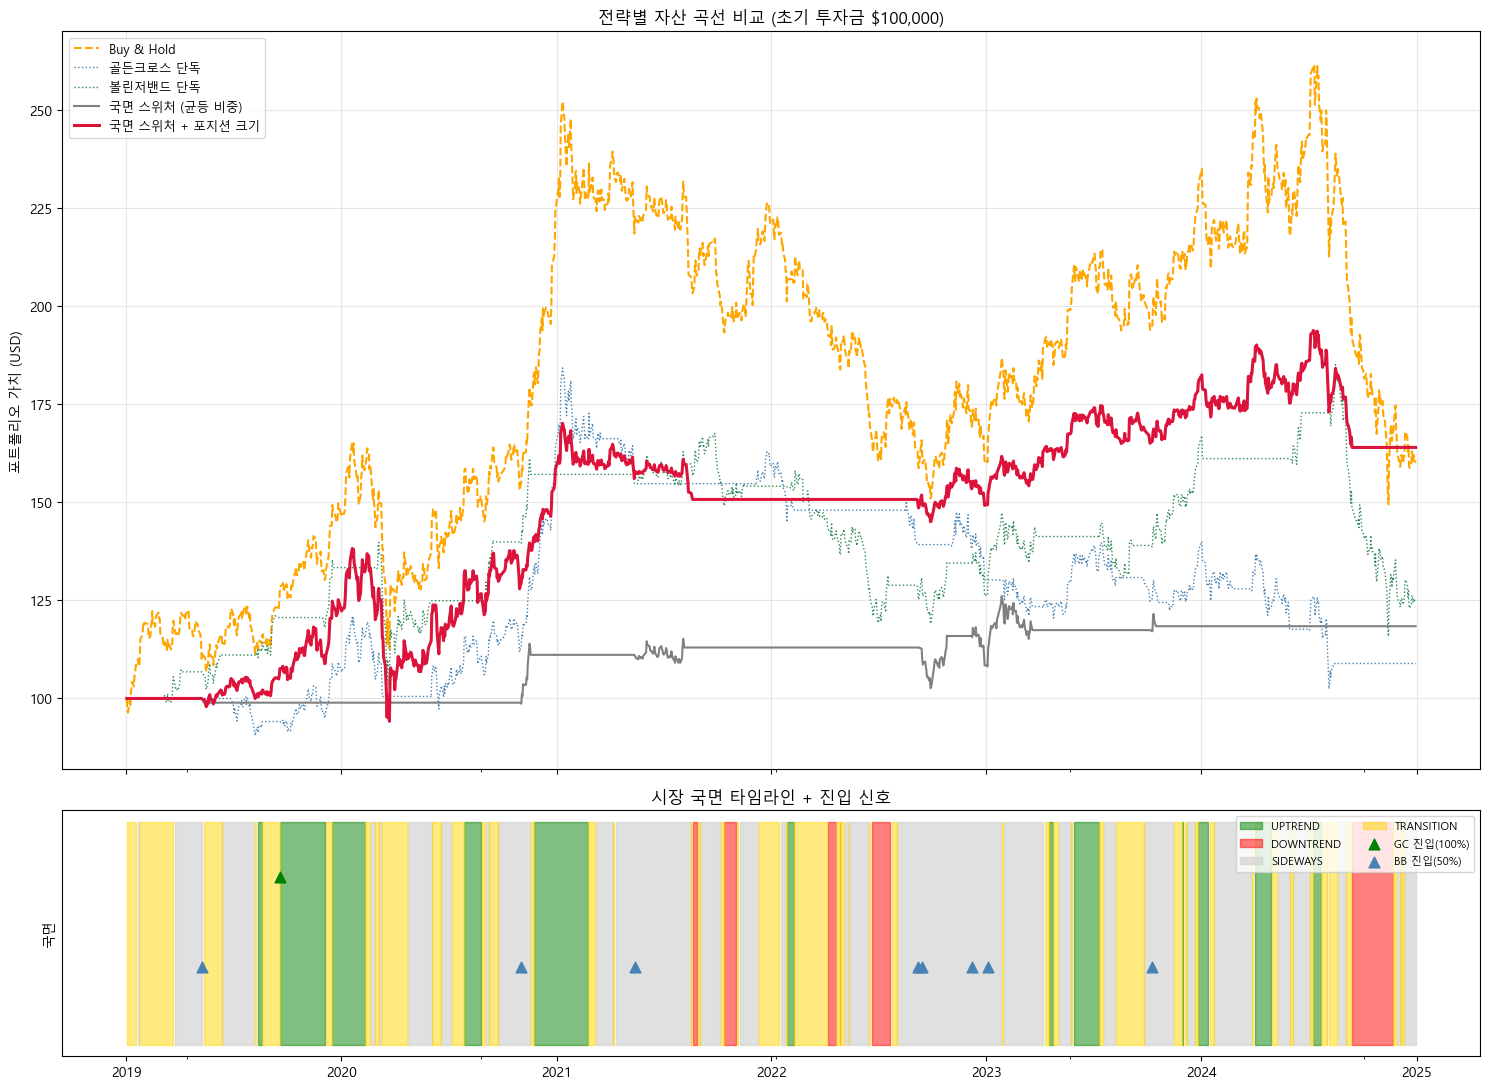

In [12]:
# ─── 자산 곡선 + 국면 타임라인 통합 차트 ─────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 11),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# 상단: 자산 곡선
style_map = {
    'Buy & Hold':               ('orange',    '--', 1.5),
    '골든크로스 단독':             ('steelblue', ':',  1.0),
    '볼린저밴드 단독':             ('seagreen',  ':',  1.0),
    '국면 스위처 (균등 비중)':      ('gray',      '-',  1.5),
    '국면 스위처 + 포지션 크기':    ('crimson',   '-',  2.2),
}

for name, pf in strategies.items():
    color, ls, lw = style_map[name]
    pf.value().plot(ax=ax1, label=name, color=color, linestyle=ls, linewidth=lw)

ax1.set_title('전략별 자산 곡선 비교 (초기 투자금 $100,000)')
ax1.set_ylabel('포트폴리오 가치 (USD)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# 하단: 국면 타임라인
regime_colors = {
    'UPTREND':    ('green',     0.5),
    'DOWNTREND':  ('red',       0.5),
    'SIDEWAYS':   ('lightgray', 0.7),
    'TRANSITION': ('gold',      0.5),
}
for r_name, (r_color, r_alpha) in regime_colors.items():
    mask = regime == r_name
    ax2.fill_between(close.index, 0, 1, where=mask,
                     color=r_color, alpha=r_alpha, label=r_name)

# 진입 신호 마커
ax2.scatter(close.index[gc_entries], [0.75]*gc_entries.sum(),
            marker='^', color='green',      s=60, zorder=5, label='GC 진입(100%)')
ax2.scatter(close.index[bb_entries], [0.35]*bb_entries.sum(),
            marker='^', color='steelblue',  s=60, zorder=5, label='BB 진입(50%)')

ax2.set_title('시장 국면 타임라인 + 진입 신호')
ax2.set_ylabel('국면')
ax2.set_yticks([])
ax2.legend(loc='upper right', fontsize=8, ncol=2)
ax2.grid(False)

plt.tight_layout()
plt.show()

---
## 정리

### 4국면 전략 설계 요약

| 국면 | 판별 조건 | 매수 | 매도 |
|------|----------|------|------|
| UPTREND | MA20>MA60>MA120 AND ADX>25 | 골든크로스 → 100% 진입 | 손절 (개별 종목) |
| DOWNTREND | MA20<MA60<MA120 AND ADX>25 | 없음 | 전량 청산 |
| SIDEWAYS | ADX < 20 | 볼린저밴드 하단 → 50% 진입 | 손절 (개별 종목) |
| TRANSITION | 위 3가지 미해당 | 없음 | 손절만 유지 (기존 포지션 유지) |

### TRANSITION 설계 원칙

```
기존 설계: TRANSITION → 전량 청산
  └ 문제: MA120 후행성으로 이미 오른 구간에서 강제 청산 → 수익 기회 손실

변경 설계: TRANSITION → 신규 진입만 차단, 기존 포지션 유지
  └ 효과: 불필요한 청산 제거, 포지션이 전략 신호(손절·데드크로스)로만 청산됨
```

### 포지션 크기 조절

```
UPTREND   (확신)   → 100% 풀 포지션  ← 수익 극대화
SIDEWAYS  (불확실) →  50% 절반 포지션 ← 손실 제한
DOWNTREND (위험)   →   0% 전량 청산  ← 손실 방어
TRANSITION(모호)   →  NaN 유지       ← 기존 포지션 그대로
```

### 손절 vs 전량 청산 구분

| 매도 방식 | 대상 | 발동 시점 |
|----------|------|----------|
| 손절 | 개별 종목 1개 | 해당 종목 -N% 손실 도달 |
| 전량 청산 | 보유 종목 전체 | 국면이 DOWNTREND 전환 시만 |

### 한계 및 주의사항
- **국면 전환 후행성**: MA120 기반이므로 국면 변화 감지에 수주 지연 발생
- **파라미터 의존성**: 20/60/120, ADX 25/20, 포지션 크기 비율 모두 최적화 대상
- **과최적화 위험**: 반드시 out-of-sample 검증 필요

### 다음 단계
`04_성과분석_최적화.ipynb` 에서 MA 기간·ADX 임계값·포지션 크기 비율을 그리드 서치로 최적화하고  
in-sample / out-of-sample 분리 검증으로 과최적화 여부를 확인합니다.